# Lecture 08d: Exploratory Data Analysis on the 'iris' dataset

### A refactoring of a nice blog that could be improved a lot.
[this blog post](https://medium.com/codex/machine-learning-k-nearest-neighbors-algorithm-with-python-df94b374ad41)

### The *iris* plants dataset, loaded from seaborn
[iris flowers](https://en.wikipedia.org/wiki/Iris_(plant))
[iris setosa](https://en.wikipedia.org/wiki/Iris_setosa)
[Iris Versicolour](https://en.wikipedia.org/wiki/Iris_versicolor)
[Iris Virginica](https://en.wikipedia.org/wiki/Iris_virginica)

[Info about dataset](https://raw.githubusercontent.com/jbrownlee/Datasets/master/iris.names)

### Import necessary modules.

In [2]:
# pandas: the main library for tabular data manipulation in Python
import pandas as pd
# numpy: for numerical operations (arrays, math functions)
import numpy as np
# seaborn: a high-level plotting library built on top of matplotlib
import seaborn as sns

# matplotlib: the foundational Python plotting library
import matplotlib.pyplot as plt
from matplotlib import style

## Examine the data, using graphs (EDA) and statistics.

In [3]:
# seaborn comes with built-in practice datasets — very handy for learning.
# load_dataset() downloads and returns a pandas DataFrame.
df = sns.load_dataset('iris')

In [4]:
type(df)

pandas.core.frame.DataFrame

In [5]:
# seaborn loads training datasets and returns a pandas dataframe which contains X and y.
df.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,species
102,7.1,3.0,5.9,2.1,virginica
53,5.5,2.3,4.0,1.3,versicolor
33,5.5,4.2,1.4,0.2,setosa
111,6.4,2.7,5.3,1.9,virginica
92,5.8,2.6,4.0,1.2,versicolor


### 1. Basic info about the data.

In [6]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [8]:
# .describe() gives count, mean, std, min, 25%, 50%, 75%, max for each numeric column.
# WARNING: Running describe() on ALL the data offers no insights about the 3 different
# species — it mixes them all together! We fix this in the next cell with groupby().
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [9]:
# Much better! groupby("species").describe() gives separate stats for each species.
# .T transposes the table so species become columns — easier to compare side by side.
df.groupby("species").describe().T

species                setosa  versicolor  virginica
sepal_length count  50.000000   50.000000  50.000000
             mean    5.006000    5.936000   6.588000
             std     0.352490    0.516171   0.635880
             min     4.300000    4.900000   4.900000
             25%     4.800000    5.600000   6.225000
             50%     5.000000    5.900000   6.500000
             75%     5.200000    6.300000   6.900000
             max     5.800000    7.000000   7.900000
sepal_width  count  50.000000   50.000000  50.000000
             mean    3.428000    2.770000   2.974000
             std     0.379064    0.313798   0.322497
             min     2.300000    2.000000   2.200000
             25%     3.200000    2.525000   2.800000
             50%     3.400000    2.800000   3.000000
             75%     3.675000    3.000000   3.175000
             max     4.400000    3.400000   3.800000
petal_length count  50.000000   50.000000  50.000000
             mean    1.462000    4.260000   5.552000
             std     0.173664    0.469911   0.551895
             min     1.000000    3.000000   4.500000
             25%     1.400000    4.000000   5.100000
             50%     1.500000    4.350000   5.550000
             75%     1.575000    4.600000   5.875000
             max     1.900000    5.100000   6.900000
petal_width  count  50.000000   50.000000  50.000000
             mean    0.246000    1.326000   2.026000
             std     0.105386    0.197753   0.274650
             min     0.100000    1.000000   1.400000
             25%     0.200000    1.200000   1.800000
             50%     0.200000    1.300000   2.000000
             75%     0.300000    1.500000   2.300000
             max     0.600000    1.800000   2.500000

### 2. Various plots for EDA

In [10]:
# Matplotlib styles
style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [11]:
# Set a consistent visual style for all matplotlib/seaborn plots in this notebook.
# rcParams lets you set global defaults like figure size.
style.use("seaborn-v0_8-whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)  # width=14 inches, height=8 inches

#### A2. Sepal scatter visualization

In [12]:
# sns.scatterplot?

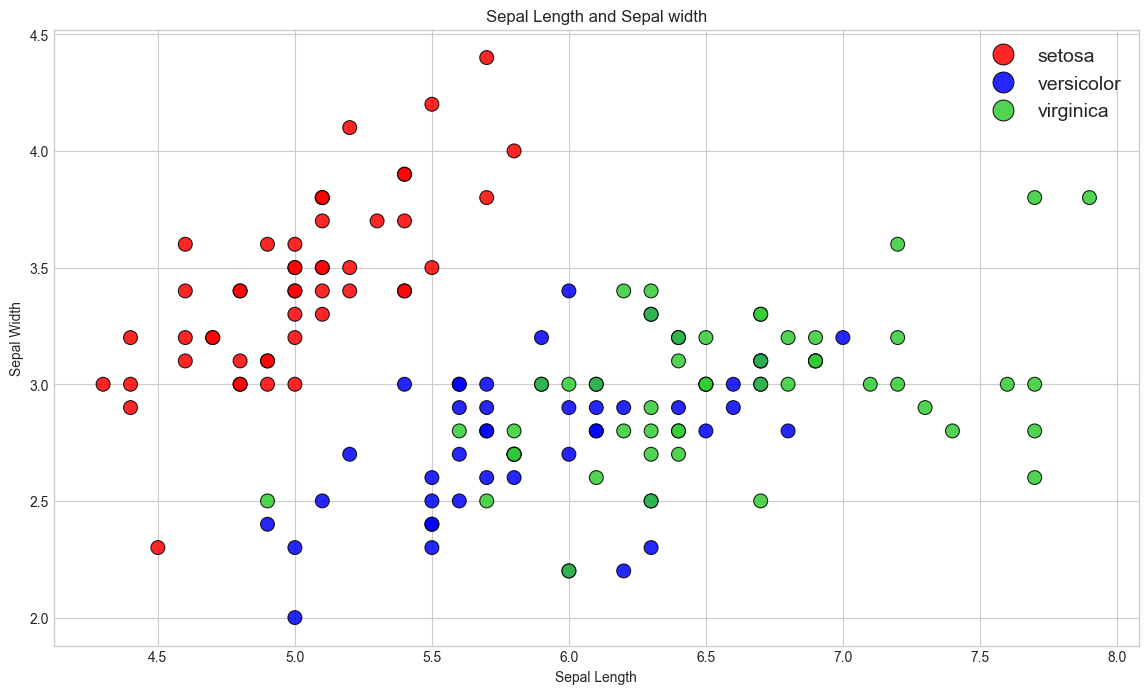

In [13]:
# Write functions with many parameters using one line for each parameter: Readability and Flexibility. Faster, cleaner coding.
sns.scatterplot(data=df,
                x='sepal_length',
                y='sepal_width',
                hue='species',
                palette=['Red', 'Blue', 'Limegreen'],
                # palette = 'Set2', # Try this one.
                edgecolor='black',
                s=100,
                alpha=0.85  # try setting 0.5
)

plt.title('Sepal Length and Sepal width')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.legend(markerscale=1.5, loc="upper right", prop={'size': 14});  # Try different marker scales.

# plt.savefig("sepal.png")  # Can you guess what does this line of code do?

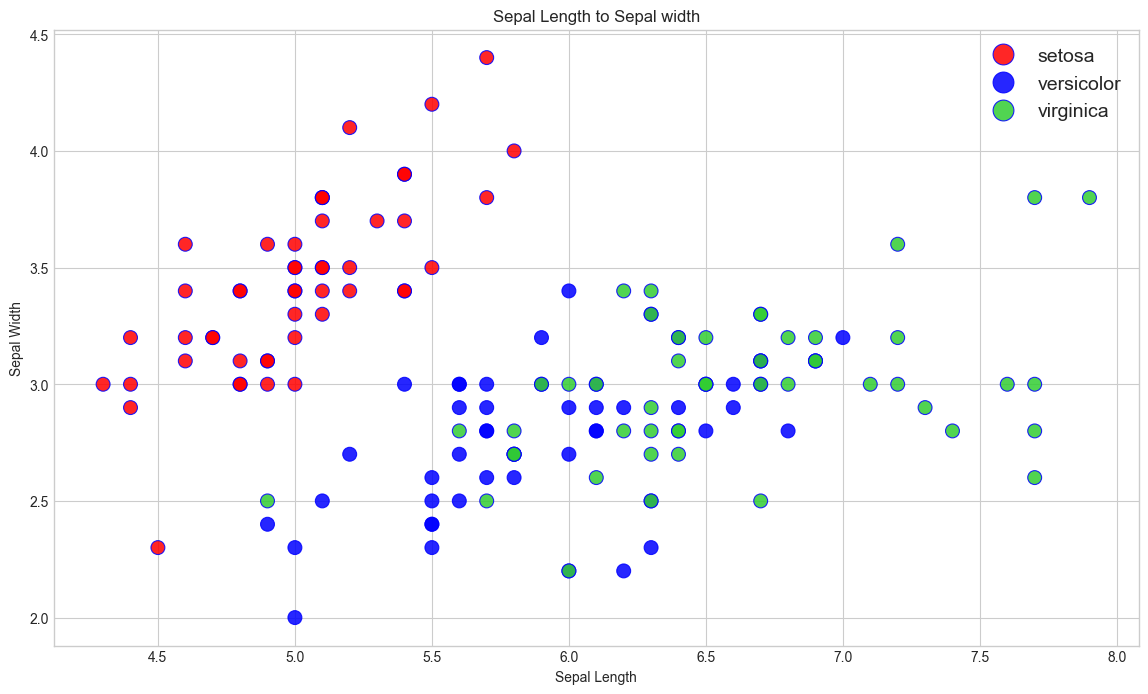

In [14]:
# Spot the three differences in the code between this plot and the one above:
# a)
# b)
# c)

# Write functions with many parameters using one line for each parameter: Readability and Flexibility. Faster, cleaner coding.
sns.scatterplot(
    x='sepal_length',
    y='sepal_width',
    data=df,  # a)
    hue='species',
    palette=['red', 'blue', 'limegreen'],  # b)
    edgecolor='b', # c) Can you guess if this is "black" or "blue"? Explicit is better than implicit.
    s=100,
    alpha=0.85
)

plt.title('Sepal Length to Sepal width')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.legend(markerscale=1.5, loc="upper right", prop={'size': 14});

# plt.savefig('sepal.png')  # Can you guess what does this line of code do?

#### A3. Petal scatter visualization

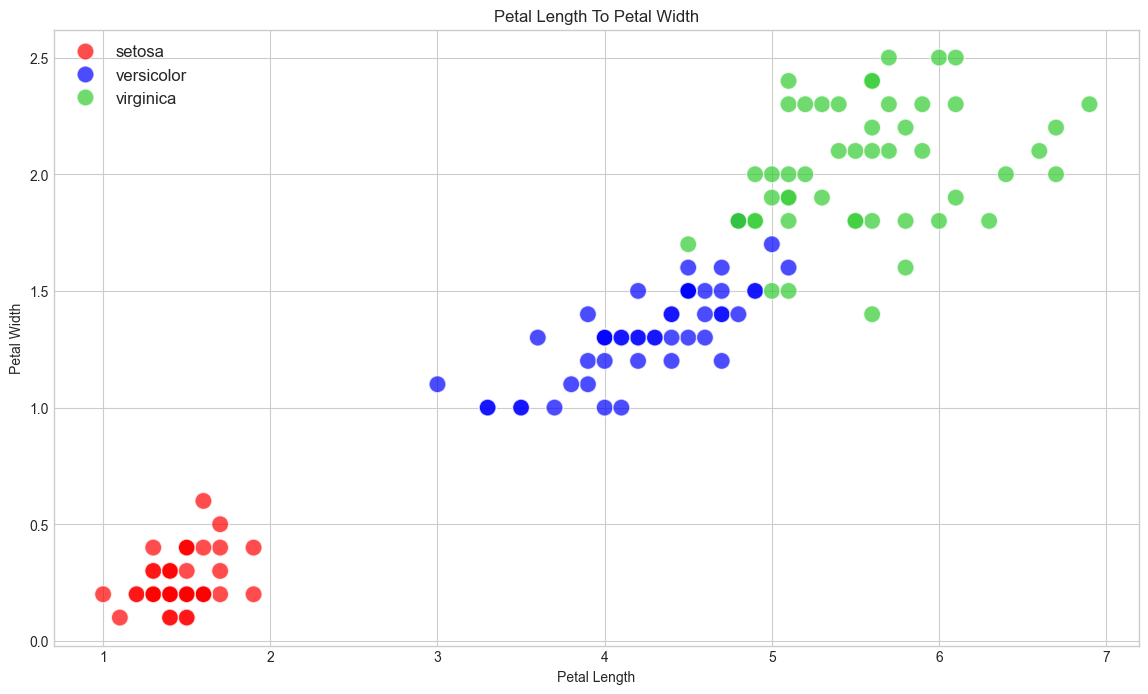

In [15]:
sns.scatterplot(
    x='petal_length', y='petal_width', data=df, hue='species',
    palette = ['Red', 'Blue', 'limegreen'],
    edgecolor = 'w', s = 150, alpha = 0.7
)

plt.title('Petal Length To Petal Width')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.legend(loc = 'upper left', fontsize = 12);

# plt.savefig('petal.png')

In [16]:
# sns.heatmap?

#### A4. Data Heatmap

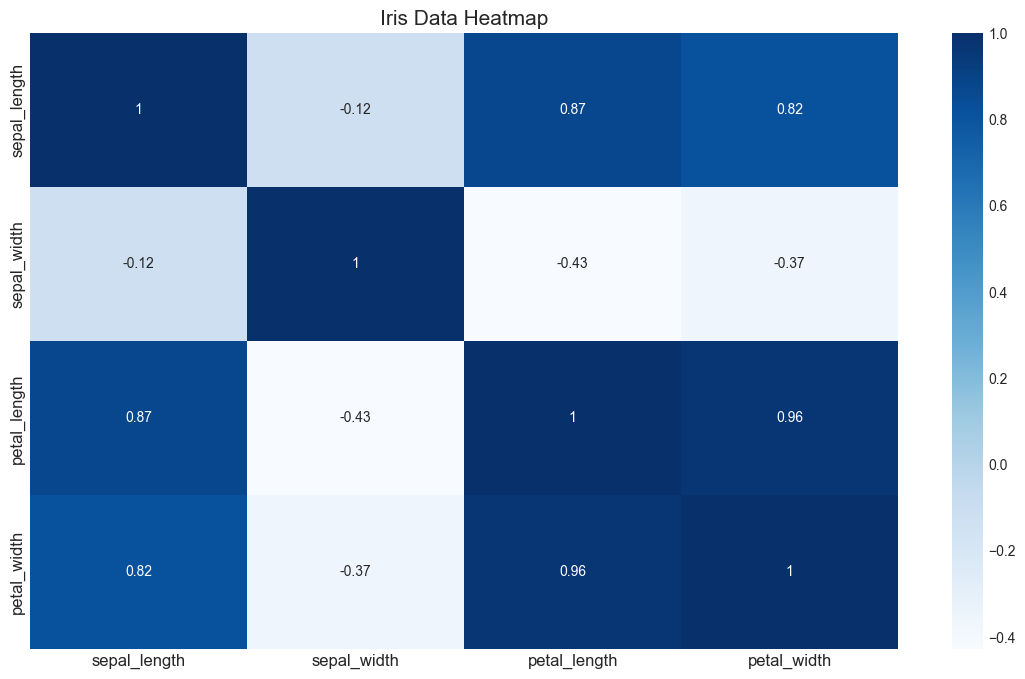

In [17]:
# A correlation heatmap shows how strongly each pair of numeric features is related.
# Values close to +1 or -1 mean strong correlation; close to 0 means weak/no correlation.
# numeric_only=True is required since pandas 2.0 (it won't silently ignore non-numeric columns).
df_corr = df.corr(numeric_only=True)

sns.heatmap(
    df_corr, annot=True, cmap='Blues',
    xticklabels=df_corr.columns.values,
    yticklabels=df_corr.columns.values
);

plt.title('Iris Data Heatmap', fontsize=15);
plt.xticks(fontsize=12);
plt.yticks(fontsize=12);

# plt.savefig('heatmap.png')  # Uncomment to save the plot as an image file

#### A5. Scatter Matrix

## Examine possibilities for feature engineering.
If new features are Linear combinations of existing features, can't have both in linear models.

petal lenght to sepal lenght.
petal width to sepal width.
Approximate area of sepal and pedal (sq.cm.)? Width * length

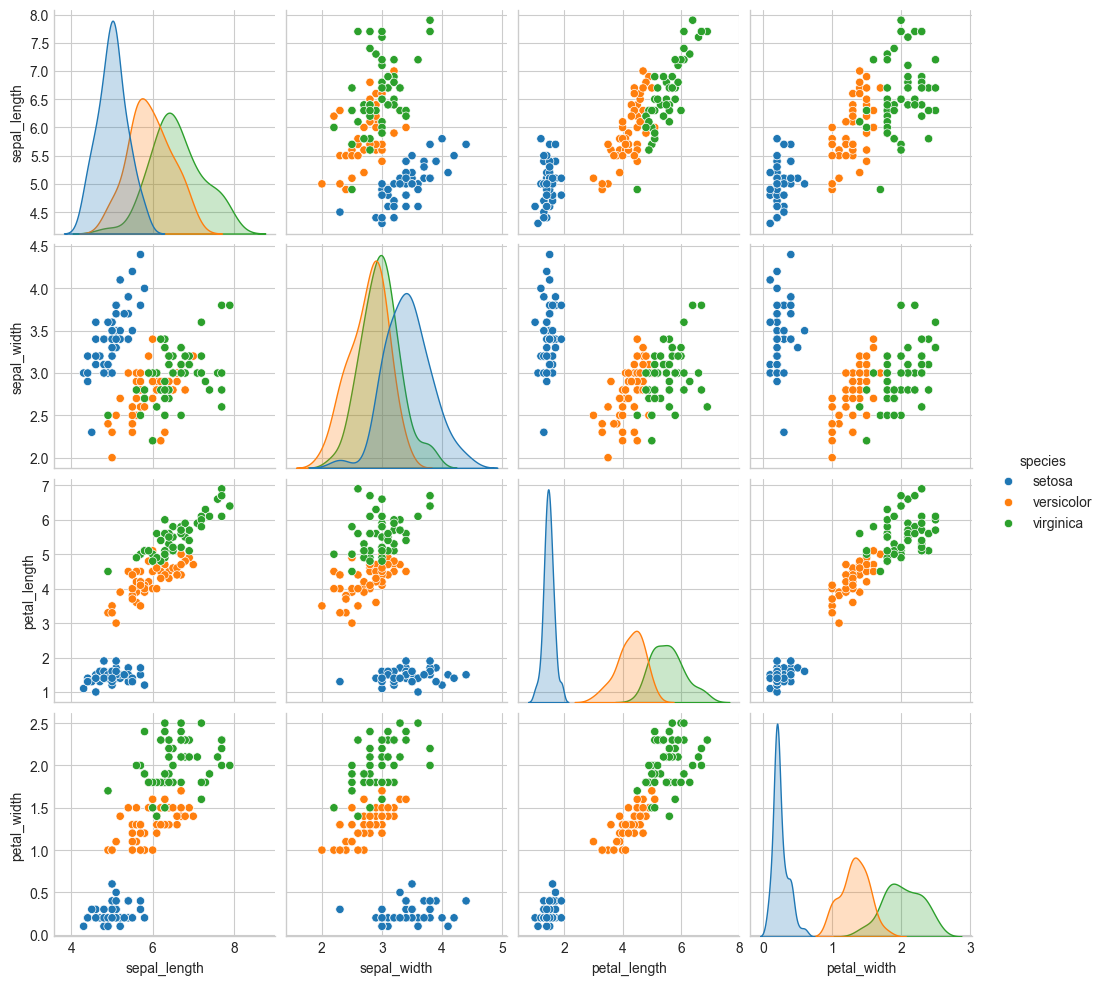

In [18]:
# A pair plot creates scatter plots for every pair of numeric features,
# with histograms on the diagonal. Coloring by 'species' reveals clusters.
# This is one of the most powerful EDA tools for spotting patterns.
sns.pairplot(data=df, hue='species')#, palette=['Red', 'Blue', 'limegreen']);

# plt.savefig('iris_pairplot.png')

In [19]:
df["approx_sepal_area"] = df.sepal_length * df.sepal_width
df["approx_petal_area"] = df.petal_length * df.petal_width
df["approx_total_area"] = df.approx_petal_area * df.approx_sepal_area

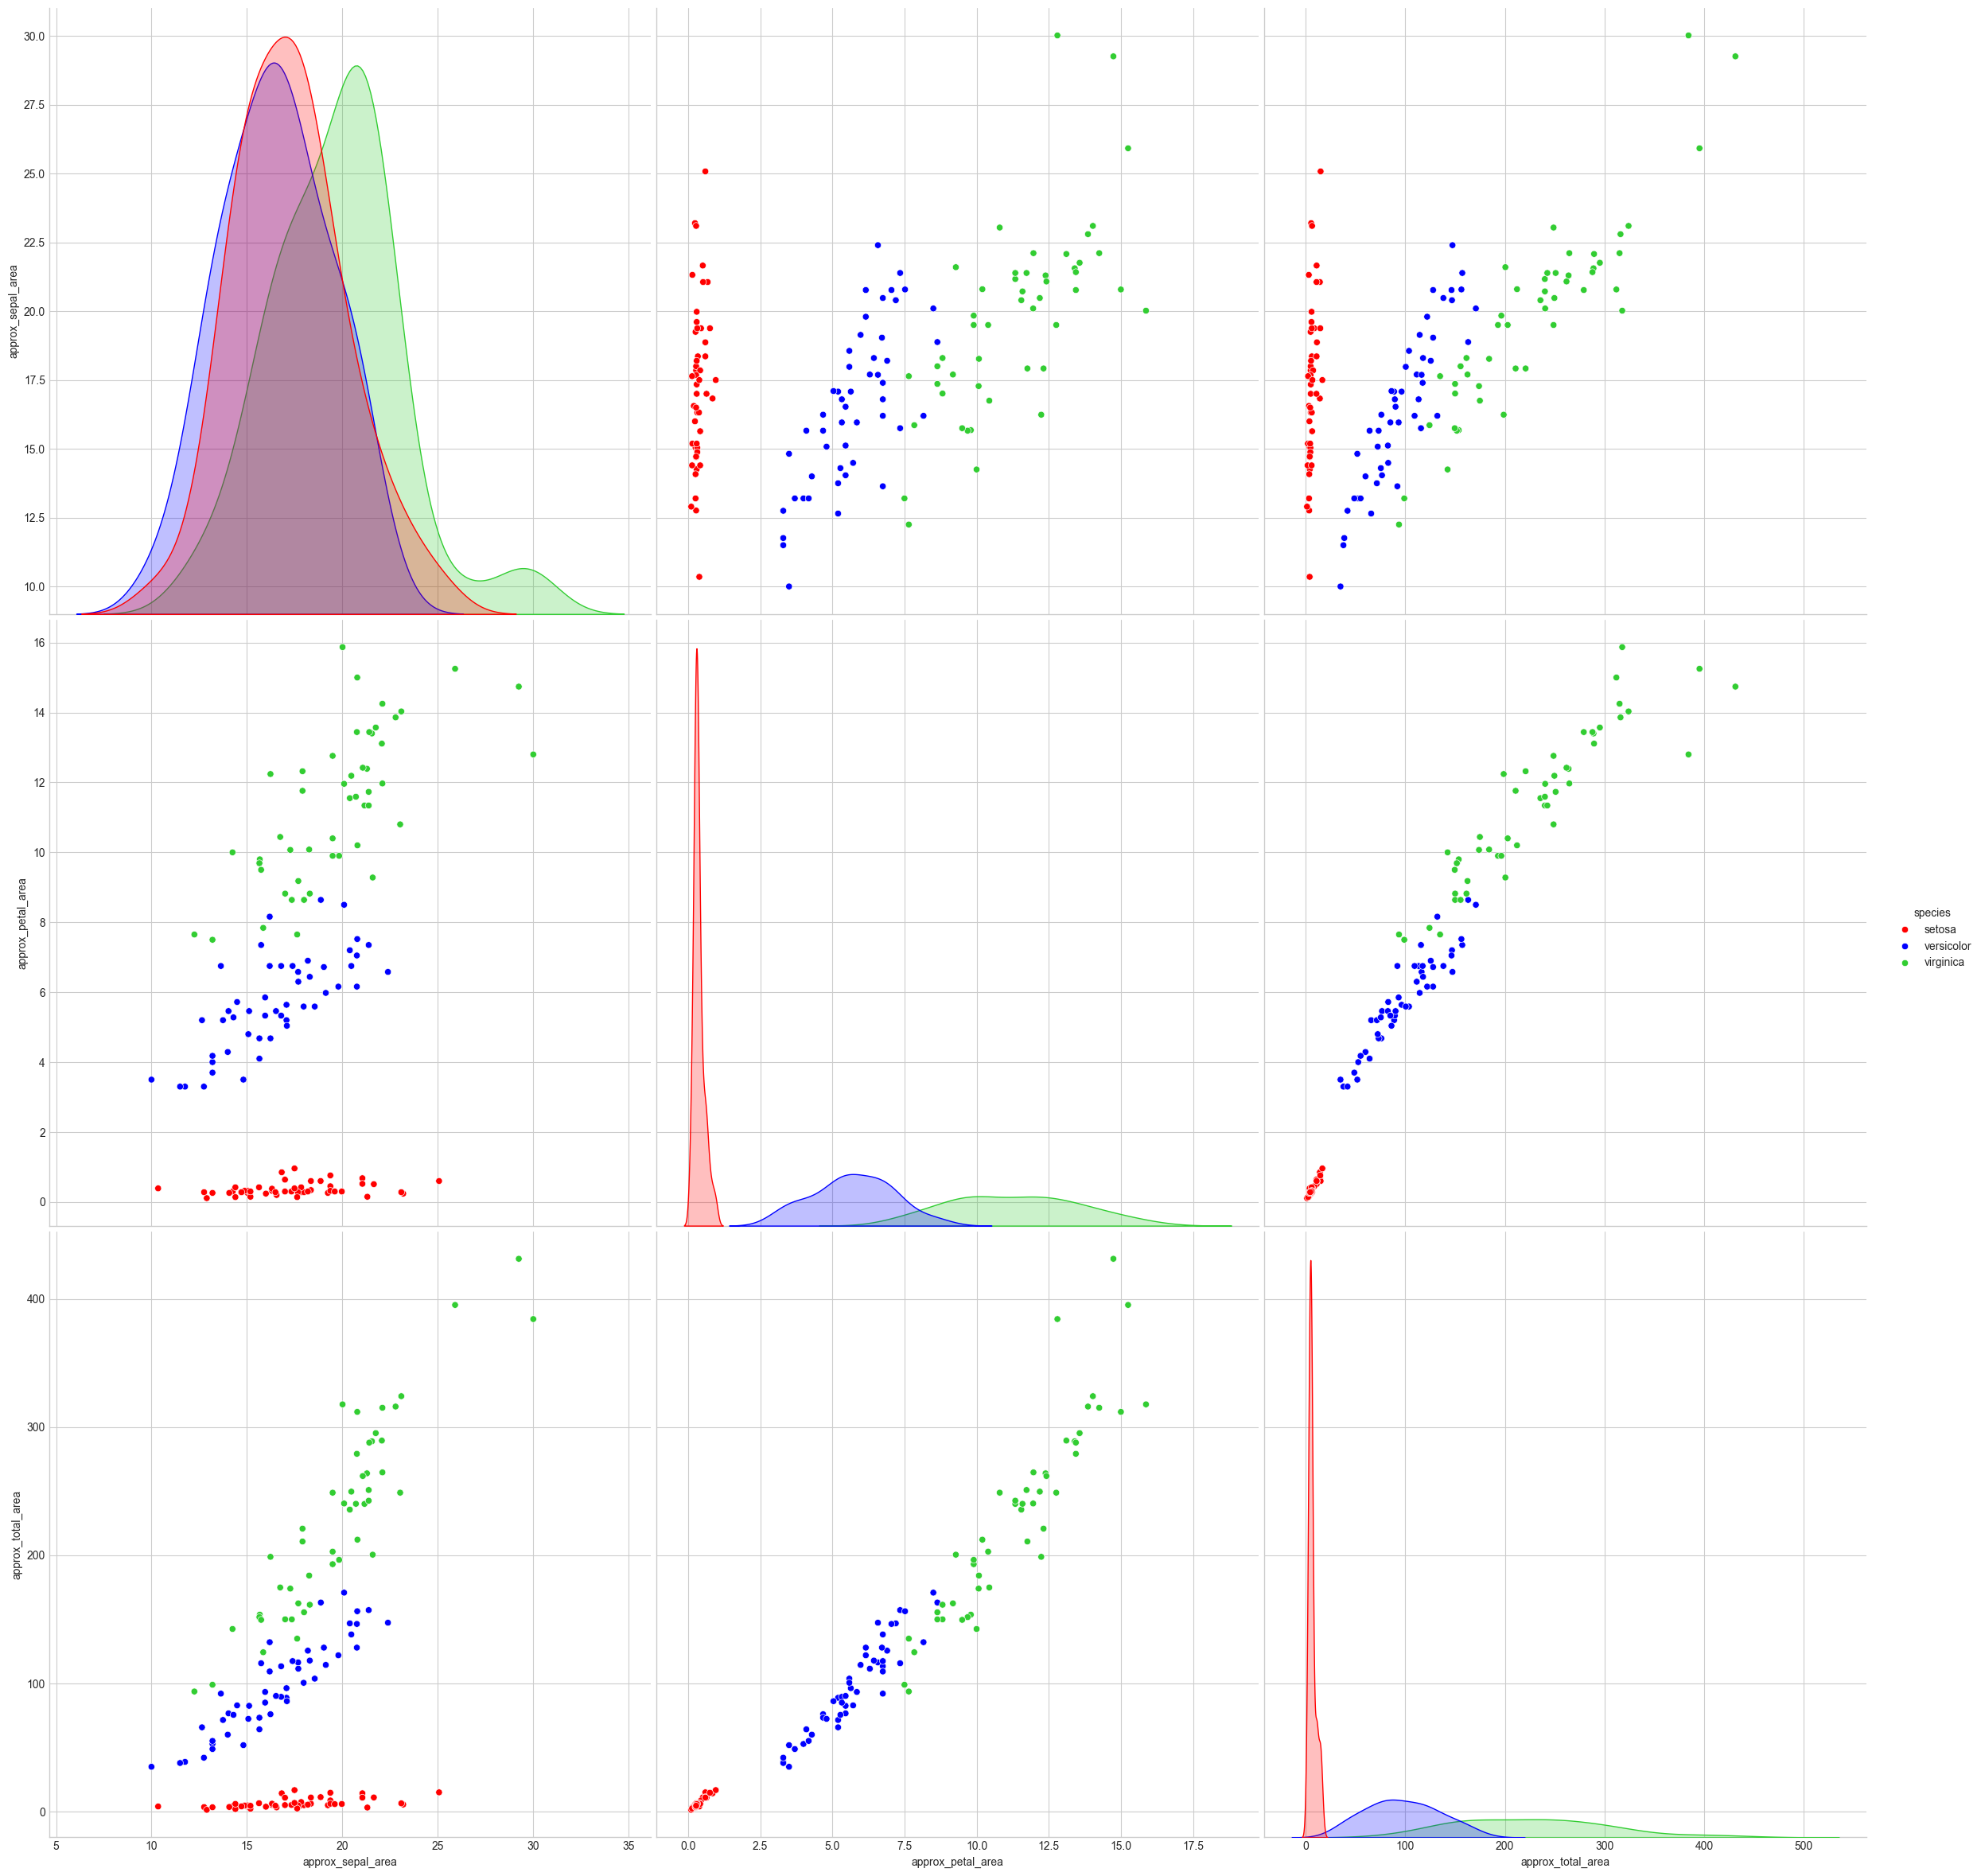

In [20]:
# use the species to 
sns.pairplot(data=df[["approx_sepal_area", "approx_petal_area", "approx_total_area", 'species']], hue='species', palette=['Red', 'Blue', 'limegreen'], height=8);


In [21]:
df["approx_sepal_ratio"] = df.sepal_length / df.sepal_width
df["approx_petal_ratio"] = df.petal_length / df.petal_width
df["approx_total_ratio"] = df.approx_petal_area / df.approx_sepal_area

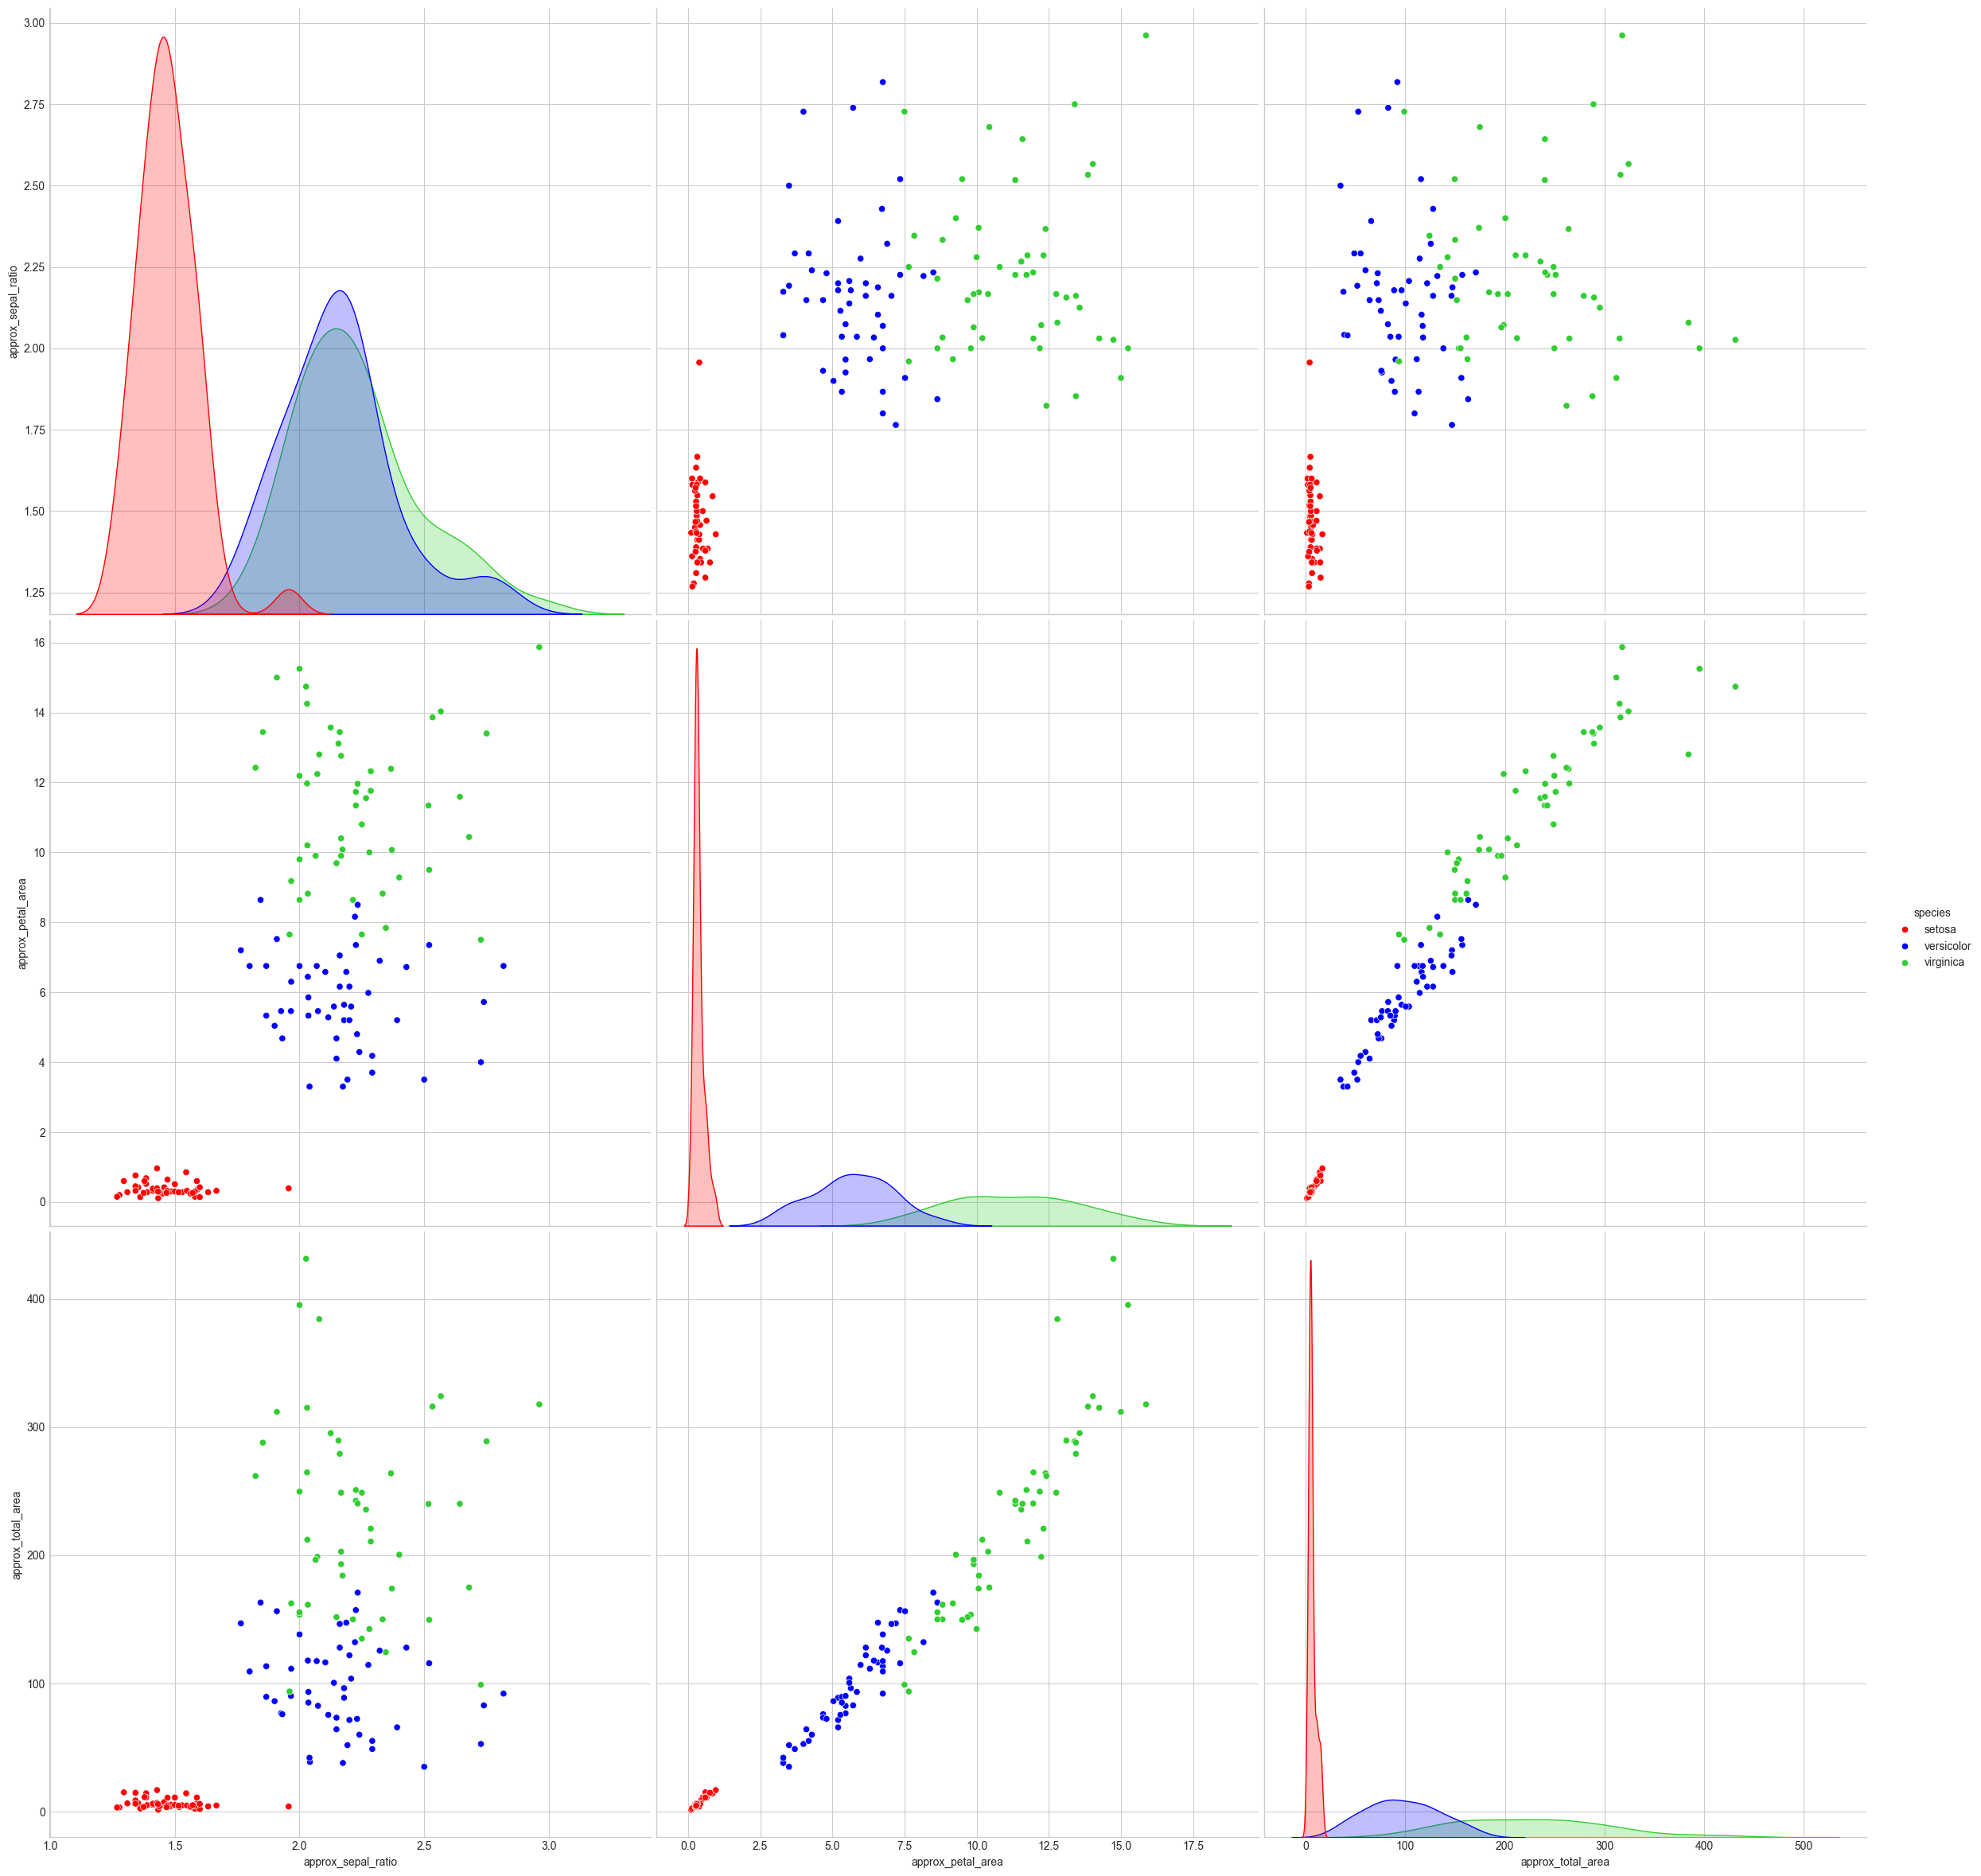

In [22]:
# use the species to 
sns.pairplot(data=df[["approx_sepal_ratio", "approx_petal_area", "approx_total_area", 'species']], hue='species', palette=['Red', 'Blue', 'limegreen'], height=8);


/tmp/ipykernel_52269/494418532.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['sepal_length'], color = 'r', shade = True)
/tmp/ipykernel_52269/494418532.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['sepal_width'], color = 'b', shade = True)
/tmp/ipykernel_52269/494418532.py:11: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['petal_length'], color = 'coral', shade = True)
/tmp/ipykernel_52269/494418532.py:12: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['petal_width'], color =

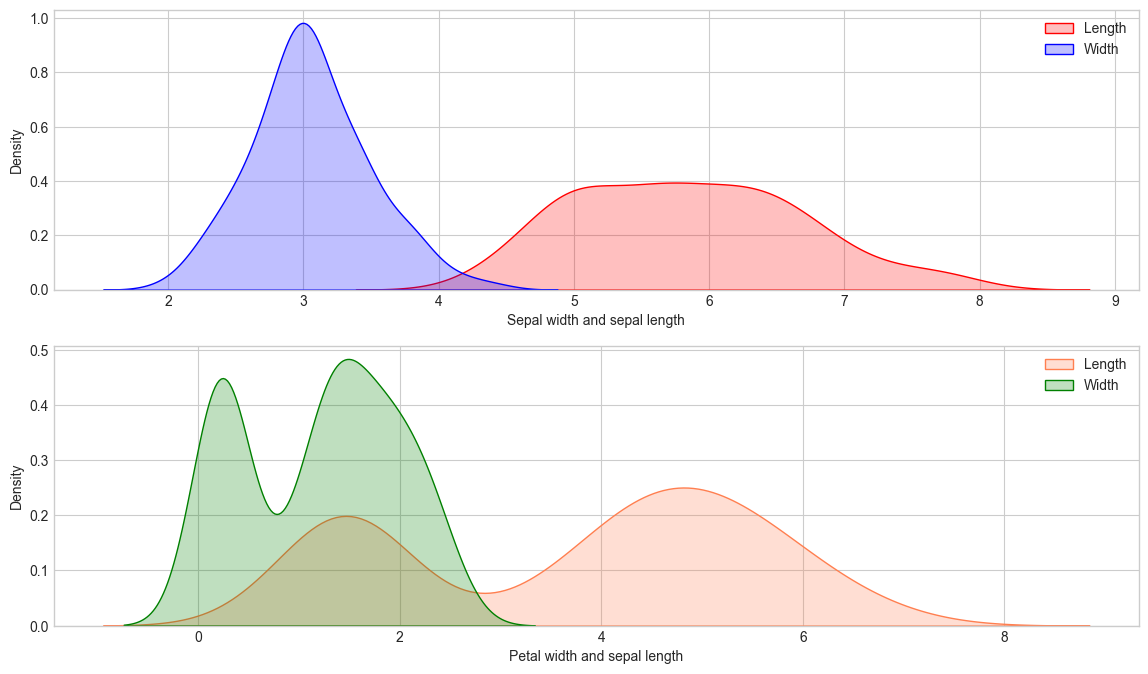

In [23]:
# 5. Distribution plot for all species of iris

ax1 = plt.subplot(211)
sns.kdeplot(df['sepal_length'], color = 'r', shade = True)
sns.kdeplot(df['sepal_width'], color = 'b', shade = True)
plt.xlabel('Sepal width and sepal length');
plt.legend(["Length", "Width"])


ax2 = plt.subplot(212)
sns.kdeplot(df['petal_length'], color = 'coral', shade = True)
sns.kdeplot(df['petal_width'], color = 'green', shade = True);
plt.xlabel('Petal width and sepal length');
plt.legend(["Length", "Width"])

# plt.savefig('dist.png')

## B. Examine outliers
BOXPLOTS

`